# **Импорты**

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# **Загрузка и распаковка данных**

In [ ]:


!wget https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip

with zipfile.ZipFile('20writers.zip', 'r') as zip_ref:
    zip_ref.extractall('writers')

--2026-04-23 07:11:40--  https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28517672 (27M) [application/x-zip-compressed]
Saving to: ‘20writers.zip.2’

20writers.zip.2     100%[===================>]  27.20M  11.5MB/s    in 2.4s    

2026-04-23 07:11:43 (11.5 MB/s) - ‘20writers.zip.2’ saved [28517672/28517672]



# **Получение данных**

In [ ]:
texts = []
labels = []

authors = os.listdir('writers')
author_names = []

fragment_len = 1000   # длина куска текста
step = 100           # шаг (перекрытие)

for file in authors:
    file_path = os.path.join('writers', file)

    author_name = file.split('.')[0]

    if author_name not in author_names:
        author_names.append(author_name)

    label = author_names.index(author_name)

    with open(file_path, encoding='utf-8') as f:
        text = f.read()

        # разбиваем текст на куски
        for i in range(0, len(text) - fragment_len, step):
            fragment = text[i:i + fragment_len]
            texts.append(fragment)
            labels.append(label)
for i in author_names:
  print(f'Автор: {i}')

Автор: Булгаков
Автор: Беляев
Автор: Шолохов
Автор: Катаев
Автор: Носов
Автор: Горький
Автор: Пушкин
Автор: Пастернак
Автор: Каверин
Автор: Лесков
Автор: Куприн
Автор: Васильев
Автор: Гончаров
Автор: Гоголь
Автор: Толстой
Автор: Лермонтов
Автор: Чехов
Автор: Достоевский
Автор: Грибоедов
Автор: Тургенев


# **Токенизация**

In [ ]:


max_words = 20000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=max_len)

y = to_categorical(labels)

# **Деление на train/test**

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,shuffle=True
)

# **Модель (LSTM)**

In [ ]:


model = Sequential()
model.add(Embedding(max_words, 128, input_length=max_len))
model.add(LSTM(128))
model.add(Dense(len(authors), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# **Обучение**

In [ ]:


history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)


Epoch 1/5
7024/7024 ━━━━━━━━━━━━━━━━━━━━ 125s 18ms/step - accuracy: 0.9946 - loss: 0.0109 - val_accuracy: 0.9927 - val_loss: 0.0127
Epoch 2/5
7024/7024 ━━━━━━━━━━━━━━━━━━━━ 120s 17ms/step - accuracy: 0.9956 - loss: 0.0088 - val_accuracy: 0.9936 - val_loss: 0.0116
Epoch 3/5
7024/7024 ━━━━━━━━━━━━━━━━━━━━ 115s 16ms/step - accuracy: 0.9963 - loss: 0.0075 - val_accuracy: 0.9918 - val_loss: 0.0179
Epoch 4/5
7024/7024 ━━━━━━━━━━━━━━━━━━━━ 115s 16ms/step - accuracy: 0.9968 - loss: 0.0066 - val_accuracy: 0.9932 - val_loss: 0.0138
Epoch 5/5
7024/7024 ━━━━━━━━━━━━━━━━━━━━ 113s 16ms/step - accuracy: 0.9972 - loss: 0.0058 - val_accuracy: 0.9935 - val_loss: 0.0132


# **Оценка и проверка на своем тексте**

In [ ]:

loss, acc = model.evaluate(X_test, y_test)
print(f"Точность на тестовой выборке: {acc:.4f}")


my_text = """
Я шел по лесу и думал о смысле жизни. Ветер тихо шелестел листьями,
а солнце пробивалось сквозь кроны деревьев...
"""

seq = tokenizer.texts_to_sequences([my_text])
padded = pad_sequences(seq, maxlen=max_len)

prediction = model.predict(padded)
predicted_author = authors[np.argmax(prediction)]

print("Нейросеть считает, что автор текста:", predicted_author)

3512/3512 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.9935 - loss: 0.0132
Точность на тестовой выборке: 0.9935
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Нейросеть считает, что автор текста: Пастернак.txt


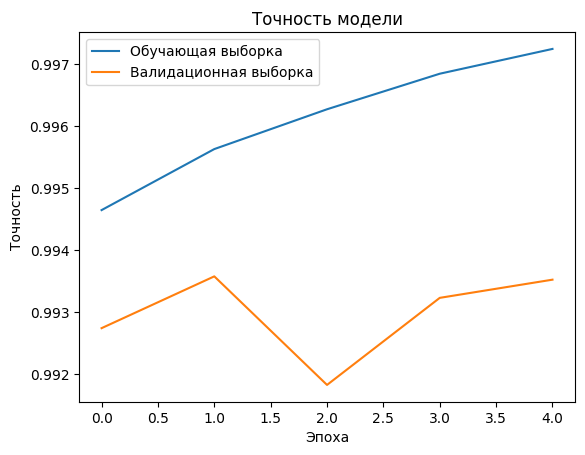

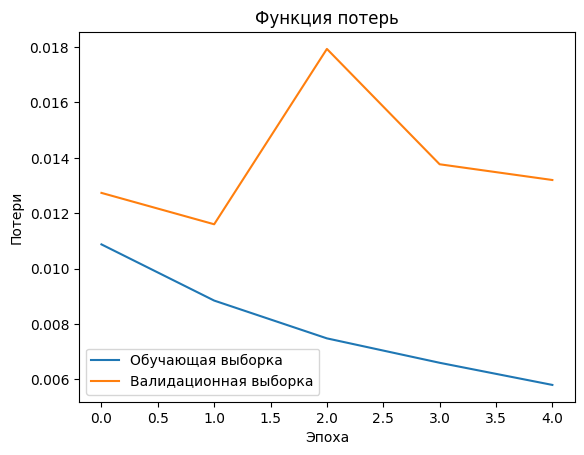

In [ ]:
import matplotlib.pyplot as plt

# График точности
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Точность модели')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend(['Обучающая выборка', 'Валидационная выборка'])
plt.show()

# График функции потерь
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Функция потерь')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.legend(['Обучающая выборка', 'Валидационная выборка'])
plt.show()